#Smart-Disease-Detection-System-for-Tomato-Plant

##Cloning from Github Repo

In [1]:
!git clone https://github.com/BenedictOkeke/Smart-Disease-Detection-System-for-Tomato-Plant.git

Cloning into 'Smart-Disease-Detection-System-for-Tomato-Plant'...
remote: Enumerating objects: 4908, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 4908 (delta 2), reused 0 (delta 0), pack-reused 4902 (from 3)
Receiving objects: 100% (4908/4908), 229.90 MiB | 34.71 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (5356/5356), done.


## Mounting from Google Drive to Google Colab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os #This is used to import folders

RAW_PATH = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/Raw"
PROCESSED_PATH = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/Processed"

In [4]:
!ls "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset"

 Augmented  'Augmented (1)'   Processed   Raw   Test   Train   Validation


##Defining Dataset Path for Easy Accessibility

In [5]:
import os

RAW_PATH = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/Raw"
PROCESSED_PATH = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/Processed"

In [6]:
os.listdir(RAW_PATH) #Checking classes of Dataset

['Tomato septoria leaf spot',
 'Tomato leaf blight',
 'Tomato leaf curl',
 'Tomato verticulium wilt',
 'Tomato healthy']

In [7]:
#Let's create process folder structure

for folder in os.listdir(RAW_PATH):
    os.makedirs(os.path.join(PROCESSED_PATH, folder), exist_ok=True)

In [8]:
#Documenting images per category in datasets

for folder in os.listdir(RAW_PATH):
    folder_path = os.path.join(RAW_PATH, folder)
    print(folder, len(os.listdir(folder_path)))

Tomato septoria leaf spot 2759
Tomato leaf blight 1308
Tomato leaf curl 514
Tomato verticulium wilt 759
Tomato healthy 470


Data Cleaning (Remove Corrupted Images)

Scrutinizing images to detect damaged images

In [9]:
from PIL import Image

corrupted = []

for root, dirs, files in os.walk(RAW_PATH):
    for file in files:
        if file.lower().endswith(('.jpg','.jpeg','.png')):
            path = os.path.join(root,file)

            try:
                with Image.open(path) as img:
                    img.verify()

            except Exception as e:
                corrupted.append((path,str(e)))

print("Corrupted images:",len(corrupted))

Corrupted images: 0


In [10]:
#Saving Corrupted Logs

log_path = "/content/drive/MyDrive/Tomato_Crop_Detection/corrupted_images_log.txt"

with open(log_path,"w") as f:
    for path,msg in corrupted:
        f.write(f"{path} -> {msg}\n")

In [11]:
#Removing Corrupted Images

for img,_ in corrupted:
    os.remove(img)

##Resizing Data Properly

In [12]:
#Importing Libraries

import cv2
import numpy as np

In [13]:
#Data Resize Function with padding

IMG_SIZE = 224

def resize_with_padding(image):

    h,w = image.shape[:2]

    scale = IMG_SIZE/max(h,w)

    new_w = int(w*scale)
    new_h = int(h*scale)

    resized = cv2.resize(image,(new_w,new_h))

    canvas = np.zeros((IMG_SIZE,IMG_SIZE,3),dtype=np.uint8)

    y_offset = (IMG_SIZE-new_h)//2
    x_offset = (IMG_SIZE-new_w)//2

    canvas[y_offset:y_offset+new_h,x_offset:x_offset+new_w] = resized

    return canvas

##Processing to Save Cleared Dataset

In [14]:
for folder in os.listdir(RAW_PATH):

    raw_class = os.path.join(RAW_PATH,folder)
    processed_class = os.path.join(PROCESSED_PATH,folder)

    for img_name in os.listdir(raw_class):

        img_path = os.path.join(raw_class,img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        processed_img = resize_with_padding(img)

        save_path = os.path.join(processed_class,img_name)

        cv2.imwrite(save_path,processed_img)

In [15]:
#Let's verify Processed Datasets

for folder in os.listdir(PROCESSED_PATH):
    path = os.path.join(PROCESSED_PATH,folder)
    print(folder,len(os.listdir(path)))

Tomato septoria leaf spot 50217
Tomato leaf blight 22072
Tomato leaf curl 7417
Tomato verticulium wilt 10058
Tomato healthy 7


## Quick Visual Label Verification

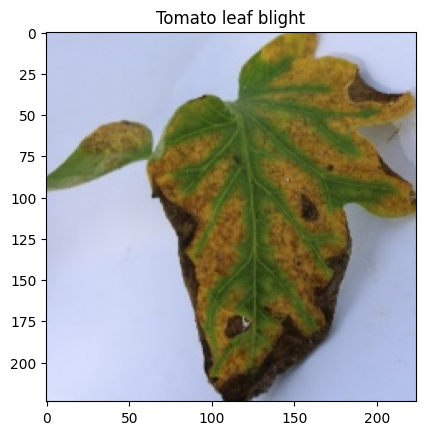

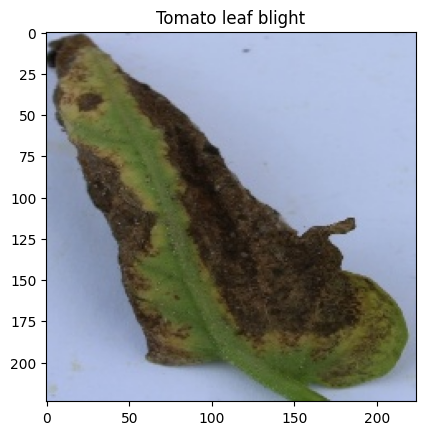

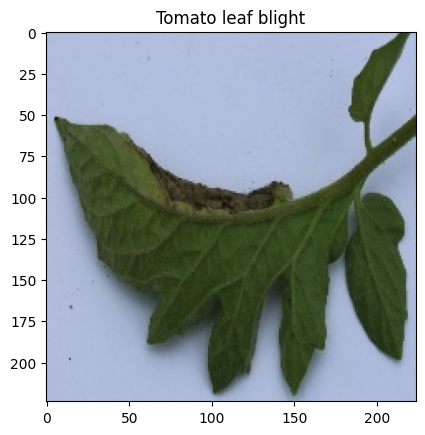

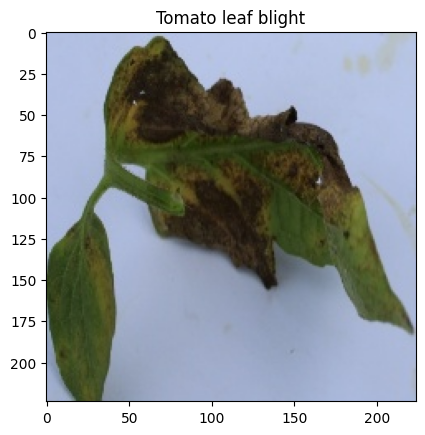

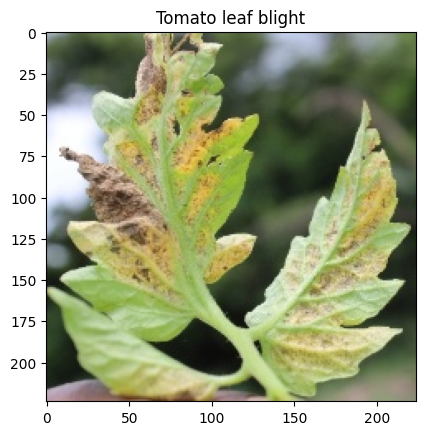

In [16]:
import random
import matplotlib.pyplot as plt

folder = "Tomato leaf blight"

path = os.path.join(PROCESSED_PATH,folder)

samples = random.sample(os.listdir(path),5)

for img in samples:
    img_path = os.path.join(path,img)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.title(folder)
    plt.show()

## Data Augmentation

## Define Datasets path

In [17]:
import os

PROCESSED_PATH = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/Processed"
AUGMENTED_PATH = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/Augmented"


## Create Augmented Dataset Folder


In [18]:
for folder in os.listdir(PROCESSED_PATH):
    os.makedirs(os.path.join(AUGMENTED_PATH, folder), exist_ok=True)

## Import Augmentation Tools

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np

## Define Augmentation Strategy

In [20]:
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    fill_mode='nearest'
)

## Generate Augmented Images

In [23]:
import cv2

for folder in os.listdir(PROCESSED_PATH):

    input_path = os.path.join(PROCESSED_PATH, folder)
    output_path = os.path.join(AUGMENTED_PATH, folder)

    for img_name in os.listdir(input_path):

        img_path = os.path.join(input_path, img_name)
        img = cv2.imread(img_path)

        img = np.expand_dims(img, axis=0)

        i = 0
        for batch in datagen.flow(img,
                                  batch_size=1,
                                  save_to_dir=output_path,
                                  save_prefix='aug',
                                  save_format='jpg'):
            i += 1
            if i > 3:
                break

ValueError: Input data in `NumpyArrayIterator` should have rank 4. You passed an array with shape (1,)

## Verify Augmented Dataset

In [ ]:
for folder in os.listdir(AUGMENTED_PATH):
    path = os.path.join(AUGMENTED_PATH, folder)
    print(folder, len(os.listdir(path)))


## Visualize Augmented Images

In [ ]:
import random
import matplotlib.pyplot as plt

folder = "Tomato leaf blight"

path = os.path.join(AUGMENTED_PATH, folder)

samples = random.sample(os.listdir(path),5)

for img in samples:
    img_path = os.path.join(path,img)
    image = cv2.imread(img_path)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

## Split Dataset for Training

In [ ]:
import os
import random
import shutil

SOURCE_DIR = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/Processed"
BASE_DIR = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset"

train_dir = os.path.join(BASE_DIR, "Train")
val_dir = os.path.join(BASE_DIR, "Validation")
test_dir = os.path.join(BASE_DIR, "Test")

for folder in os.listdir(SOURCE_DIR):

    class_path = os.path.join(SOURCE_DIR, folder)
    images = os.listdir(class_path)

    random.shuffle(images)

    train_split = int(0.7 * len(images))
    val_split = int(0.85 * len(images))

    train_images = images[:train_split]
    val_images = images[train_split:val_split]
    test_images = images[val_split:]

    os.makedirs(os.path.join(train_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(val_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(test_dir, folder), exist_ok=True)

    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, folder))

    for img in val_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(val_dir, folder))

    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_dir, folder))

print("Dataset split complete")

# Model Engineering

## To import Libraries

In [ ]:
# Let's import the libraries

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### Defining Dataset Paths

In [ ]:
train_dir = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/processed/train"
val_dir = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/processed/validation"
test_dir = "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset/processed/test"

In [ ]:
# check folder
!ls "/content/drive/MyDrive/Tomato_Crop_Detection/Dataset"

### Define image and training parameters

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

### Data Generators

In [ ]:
# Load images and perform light or real-time augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 15,
    zoom_range = 0.1,
    horizontal_flip = True,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

# Preprocessing_function ensures images match
val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

# The format MobileNet expects
test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
    )

### Load Datasets From Directory

In [ ]:
train_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical"
)

test_generator = test_datagen.flow_from_directory(test_dir, target_size = IMG_SIZE,
                                                  batch_size = BATCH_SIZE,
                                                  class_mode = "categorical")

### Load Pretrained MobileNet Model

In [ ]:
# Include_top=False (removes the original classifier)
# So we can add our own tomato disease classifier

base_model = MobileNet(

    weights = "imagenet",
    include_top = False,
    input_shape = (224,224,3)

)

### Freeze Base Model Layers

In [ ]:
# Prevents pretrained layers from updating
# during initial training phase

for layer in base_model.layers:
    layer.trainable = False


### Build Custom Classifier

In [ ]:
# Add new layers for tomato disease classification

x = base_model.output

# convert  features maps into a vector
x = GlobalAveragePooling2D()(x)

# Fully connected layer
x = Dense(128, activation = "relu")(x)

# Dropout layer to prevent  overfitting
x = Dropout(0.5)(x)

# Final output layer
predictions = Dense(train_generator.num_classes, activation = "softmax")(x))


### Build the final model

In [ ]:
model = Model(inputs = base_model.input, outputs = predictions)

### Compile the model

In [ ]:
# Adam optimizer for efficient training

model.compile(optimizer = Adam(leaening_rate = 0.0001),
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])


## View Model Architecture

In [ ]:
model.summary()

### Defining Professional Training Callbacks

In [ ]:
# EarlyStopping stops training when validation
# performance stops improving

early_stop = EarlyStopping(monitor = "val_loss", patience = 3, restore_best_weights = True)

# ModelCheckpoint saves the best model automatically
checkpoint = ModelCheckpoint("/content/drive/MyDrive/models/best_mobilenet_model.h5", monitor = "val_accuracy", save_best_only = True, verbose = 1)

### Train the model

In [ ]:
history = model.fit(
    train_generator,
    validation_data = val_generator, epochs = EPOCHS, callbacks = [early_stop, checkpoint]
)

### Fine tune the model

In [ ]:
from IPython.core.inputtransformer2 import find_end_of_continued_line
# Unfreeze last layers of MobileNet so they
# can adapt to tomato disease features

for layer in base_model.layers[-20]:
    layer.trainable = True


# Recompile with smaller learing rate
model.compileO(optimizer = Adam(learning_rate = 0.00001), loss = "categorical_crossentropy", metrics = ["accuracy"])

# Continue training
fine_tune_epochs = 5
history_fine _ model.fit(train_generator, validation_data = val_generator, epochs = fine_tune_epochs)

### Evaluate Model Performance

In [ ]:
# Test on unseen images
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

## Let's Save The final Model

In [ ]:
# This model will be used by the Model Evaluation Team

model.save("/content/drive/MyDrive/models/final_model.h5")